# Train scVI model

**KA Notes**
- Here we are taking the neuron subset (from the seurat transferred labels) and using scvi to make a neuron umap
- I think when MC did this, she did not subset using the 1000 transcripts/cell cutoff
- I will run the subclustering twice, once without the 1000 transcripts/cell cutoff to make sure I can recapitulate MC umap, and then again with the 1000 transcript/cell cutoff

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [1]:
import os
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse, csr_matrix
import scvi
import numpy as np
from collections import Counter
import anndata as ad
import matplotlib.pyplot as plt
from lightning.pytorch import seed_everything
import random
import torch
import sys
import session_info
import pandas as pd

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random.seed(0)
seed_everything(0)

scvi.settings.seed = 0
scvi.settings.num_workers = 32

Seed set to 0
Seed set to 0


## Set paths, import data

In [3]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR
base_dir = BASE_DIR

# global labeled adata
input_dir = BASE_DIR / "data/h5ad/export_03/03a_seurat"
input_h5ad = input_dir / "adata-merged-labels.h5ad"

# # reporter identification
# reporter_input_dir = BASE_DIR / "data/h5ad/export_03/03b_thresholds"
# reporter_barcodes = reporter_input_dir / "reporter_classes_gaussian_thresholds.csv"

# location for scvi outputs
scvi_dir = base_dir / 'scvi/models'

#outputs
output_dir = base_dir/ 'data/h5ad/export_04/04a_neurons'
output_dir.mkdir(parents=True, exist_ok=True)

# input_dir = base_dir / "data/h5ad/export_03/03b_thresholds"
# input_h5ad = input_dir / "adata-labeled.h5ad"

print(base_dir)

/home/workspace/DRG/spatial_mouse_drg_outputs/yano


### Load adata

In [4]:
# this is the global labeled adata object, including with the thresholded 
adata_global = sc.read_h5ad(input_h5ad)

In [5]:
adata_global

AnnData object with n_obs × n_vars = 72778 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.

In [6]:
print(min(adata_global.obs['total_counts']))

51.0


In [7]:
adata_global.obs.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,prediction.score.Macrophage_1,prediction.score.Cycling.SGC,prediction.score.Pericyte,prediction.score.Macrophage_2,prediction.score.Fibroblast_2,prediction.score.Angiogenic.EC,prediction.score.Fibroblast_1,prediction.score.max,cell_type,cell_class
aaaacmnk-1-0,aaaacmnk-1,226.557434,3029.284180,80,0,0,0,0,0,80.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.784352,SGC,Non-neuron
aaababeb-1-0,aaababeb-1,271.645538,3121.138428,242,0,0,0,0,0,242.0,...,0.0,0.0,0.050244,0.0,0.028384,0.0,0.58853,0.588530,Fibroblast_1,Non-neuron
aaaegioj-1-0,aaaegioj-1,300.646088,3117.702881,141,0,0,0,0,0,141.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.919393,Schwann_cell,Non-neuron
aadidbcn-1-0,aadidbcn-1,251.569107,3279.324219,131,0,0,0,0,0,131.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.591246,SGC,Non-neuron
aaeepbcc-1-0,aaeepbcc-1,371.284851,3147.021484,90,0,0,0,0,0,90.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,1.000000,Schwann_cell,Non-neuron


## Prepare adata

In [8]:
adata = adata_global[adata_global.obs["cell_class"] == "Neuron"].copy()

In [9]:
adata_filt = adata[adata.obs["total_counts"] >= 1000].copy() # Neuron-specific QC filter
adata_unfilt = adata.copy()

In [10]:
print(adata_unfilt.shape)
print(adata_filt.shape)


(21660, 475)
(10276, 475)


In [12]:
adata_filt

AnnData object with n_obs × n_vars = 10276 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.

In [13]:
print("adata.X is sparse:", issparse(adata_filt.layers['counts']))
print(
    "adata.X has only whole numbers:", np.all(adata_filt.layers['counts'].data == np.round(adata_filt.layers['counts'].data))
)

adata.X is sparse: True
adata.X has only whole numbers: True


# scVI

In [14]:
def train_scvi_model(adata, model_name, scvi_dir, output_dir, latent_key_suffix=""):
    print(f"\n Training {model_name}")

    # Setup for scVI
    scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="slide_id")

    # Initialize model
    model = scvi.model.SCVI(adata, gene_likelihood="nb")

    # Train model
    model.train(
        accelerator="gpu", early_stopping=True, early_stopping_patience=20
    )

    # Save model
    model_save_dir = os.path.join(scvi_dir, model_name)
    model.save(model_save_dir, overwrite=True)

    # Plot ELBO loss curves
    plt.plot(model.history["elbo_train"], label="Train ELBO Loss")
    plt.plot(model.history["elbo_validation"], label="Validation ELBO Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f"{model_name} SCVI Training Loss")
    plt.tight_layout()
    plt.show()

    # Add latent representation
    latent_key = f"X_scVI_{model_name}"
    adata.obsm[latent_key] = model.get_latent_representation(adata).astype(np.float32)

    # Save AnnData
    os.makedirs(output_dir, exist_ok=True)
    filename = os.path.join(output_dir, f"{model_name}_adata.h5ad")
    adata.write_h5ad(filename, compression="gzip")

    print(f"Saved model + latent to {filename} ({latent_key})")

    return model, adata

In [15]:
output_dir

PosixPath('/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_04/04a_neurons')


 Training neuron_filt


/home/workspace/environment/sc-scvi/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/workspace/environment/sc-scvi/l

Epoch 355/400:  89%|████████▉ | 355/400 [03:20<00:25,  1.77it/s, v_num=1, train_loss_step=554, train_loss_epoch=552]
Monitored metric elbo_validation did not improve in the last 20 records. Best score: 549.956. Signaling Trainer to stop.


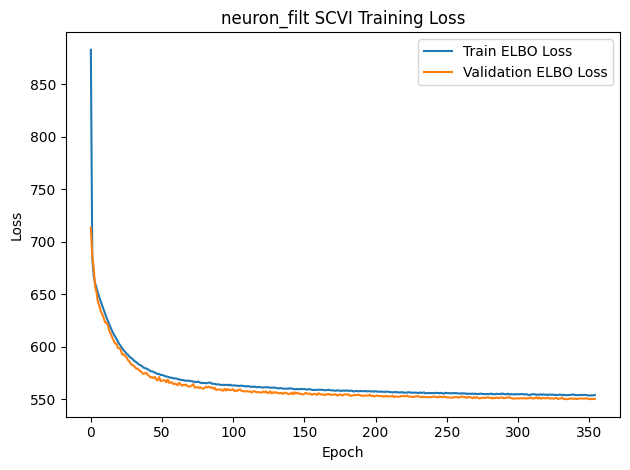

Saved model + latent to /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_04/04a_neurons/neuron_filt_adata.h5ad (X_scVI_neuron_filt)


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: nb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

(,
 AnnData object with n_obs × n_vars = 10276 × 475
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'predic

In [16]:
train_scvi_model(adata_filt, "neuron_filt", scvi_dir, output_dir)


/home/workspace/environment/sc-scvi/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/workspace/environment/sc-scvi/l


 Training neuron_unfilt
Epoch 369/369: 100%|██████████| 369/369 [07:10<00:00,  1.16s/it, v_num=1, train_loss_step=442, train_loss_epoch=446]

`Trainer.fit` stopped: `max_epochs=369` reached.


Epoch 369/369: 100%|██████████| 369/369 [07:10<00:00,  1.17s/it, v_num=1, train_loss_step=442, train_loss_epoch=446]


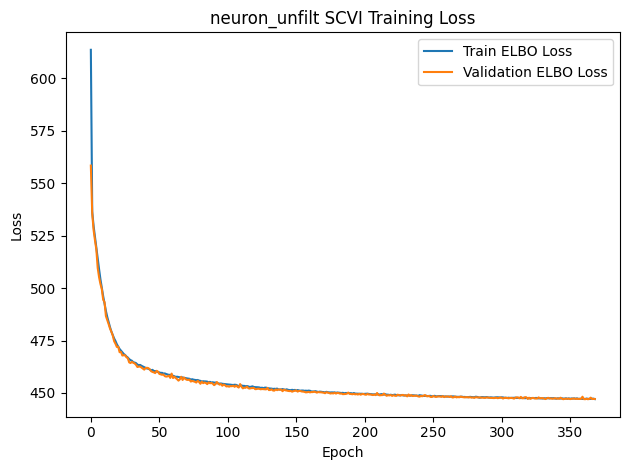

Saved model + latent to /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_04/04a_neurons/neuron_unfilt_adata.h5ad (X_scVI_neuron_unfilt)


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: nb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

(,
 AnnData object with n_obs × n_vars = 21660 × 475
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'predic

In [17]:
train_scvi_model(adata_unfilt, "neuron_unfilt", scvi_dir, output_dir)